<a href="https://colab.research.google.com/github/liv3812/vibes/blob/main/BASE_Trabalho_Final-%20frequencia%20natural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importar as Bibliotecas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os

Ler os dados do arquivo do ensaio

In [ ]:
f1t2 = pd.read_csv('/content/baja_front_rig1_carga_centro_turma2.txt', sep='\t', skiprows=10, encoding='latin1')
f1t2.set_index('Time (s)', inplace = True)
f1t2.rename(columns={"AI 1/AI 1 (m/s2)": "Acc1 m/s2", "AI 2/AI 2 (m/s2)": "Acc2 m/s2", "AI 3/AI 3 (V)": "Força (V)", "AI 4/AI 4 (V)": "Disp (V)" },  inplace = True)

Tabela dos dados lidos

In [ ]:
f1t2

,Acc1 m/s2,Acc2 m/s2
Time (s),,
0.00000,0.011754,0.008941
0.00005,0.011003,0.010158
0.00010,0.011223,0.010419
0.00015,0.011592,0.009358
0.00020,0.012700,0.010860
...,...,...
11.23175,-0.004062,-0.007416
11.23180,-0.003041,-0.000365
11.23185,-0.005660,-0.003670


Gráfico da medição

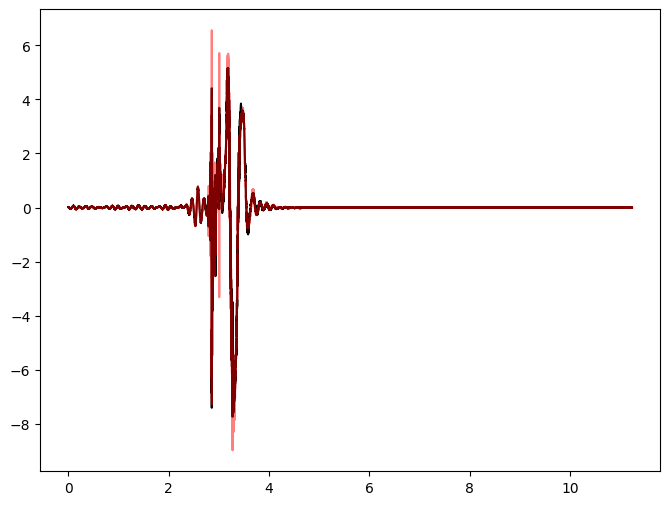

In [ ]:
fig, ax = plt.subplots(figsize=[8,6])

ax.plot(f1t2.index, f1t2['Acc1 m/s2'], 'k', label = 'Acc 1')
ax.plot(f1t2.index, f1t2['Acc2 m/s2'], 'r', label = 'Acc 2', alpha = 0.5)

Queremos caracterizar o amortecimento. Para isso, precisamos ver o decaimento da resposta. Entretanto, parte da resposta medida está muito relacionada à variação da entrada. Por isso, vamos verificar o decaimento apenas na parte final da resposta:

In [1]:
#Cortar região de interesse
u_np = np.array(f1t2.loc[3.1:4.25]['Acc1 m/s2'])
time_np = np.array(f1t2.loc[3.1:4.25].index) # Aligned time_np to u_np's range

# Plotando os resultados
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_np, y=u_np, mode='lines', name='Acc1 m/s2 (Filtered)', line=dict(color='red')))

fig.update_layout(
    xaxis_title='Tempo(s)',
    yaxis_title='Aceleração (m/s^2)'
)

fig.show()

NameError: name 'np' is not defined

Para encontrar a frequência natural do sistema subamortecido, vamos utilizar a Transformada Rápida de Fourier (FFT) na seção de interesse da aceleração.

In [2]:
from scipy.fft import fft, fftfreq

# Calculate sampling frequency
dt = time_np[1] - time_np[0]
sampling_frequency = 1 / dt

# Perform FFT
N = len(u_np)
yf = fft(u_np)
xf = fftfreq(N, dt)[:N//2]

# Get the magnitude of the FFT
freq_magnitude = 2.0/N * np.abs(yf[0:N//2])

# Find the peak frequency (natural frequency)
peak_frequency_idx = np.argmax(freq_magnitude)
natural_frequency = xf[peak_frequency_idx]

print(f"Frequência de amostragem: {sampling_frequency:.2f} Hz")
print(f"Frequência natural (aproximada): {natural_frequency:.2f} Hz")

NameError: name 'time_np' is not defined

Agora, vamos visualizar o espectro de frequência para confirmar a frequência natural.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(xf, freq_magnitude)
plt.title('Espectro de Frequência da Aceleração')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 50) # Limit x-axis to a relevant range, adjust as needed
plt.grid(True)
plt.show()

NameError: name 'xf' is not defined

<Figure size 1000x600 with 0 Axes>